In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

import pandas as pd
from google.colab import files

In [ ]:
seed = 1234
np.random.seed(seed)

In [ ]:
uploaded = files.upload()

# Carregando o CSV que foi enviado para o Google Colab
df = pd.read_csv('linearization.csv', header=None)  # Supondo que o arquivo se chama training.csv
x = (df[0].to_numpy())
y = df[1].to_numpy()
x = x.reshape(np.size(x),1)
y = y.reshape(np.size(y),1)

Saving linearization.csv to linearization (5).csv


In [ ]:
print(np.size(x))

1000


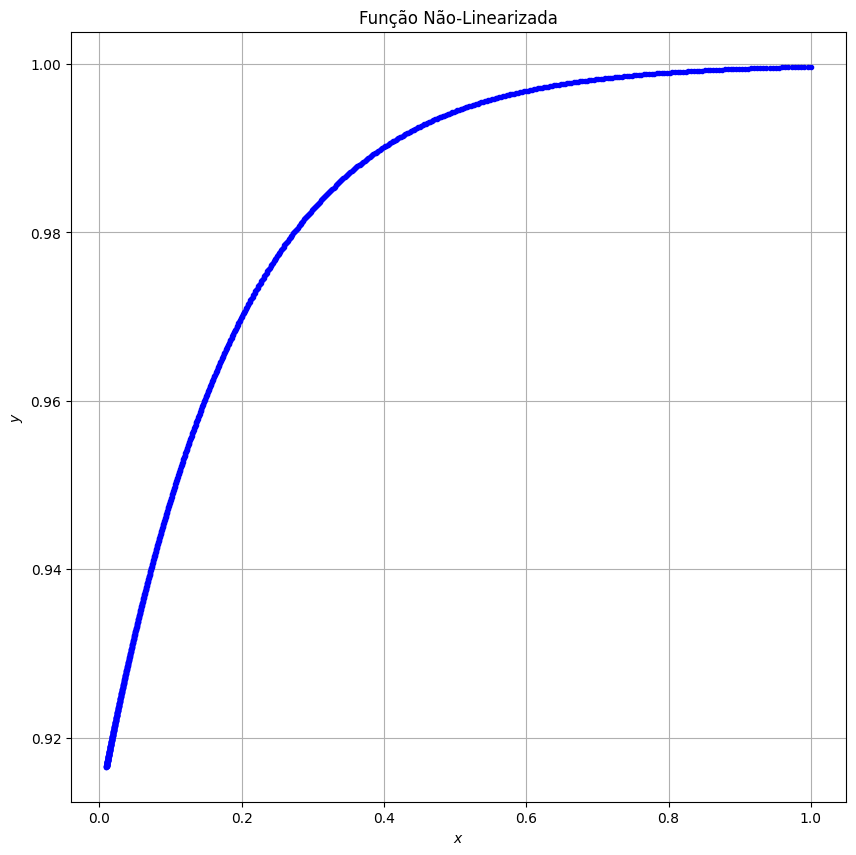

In [ ]:
# Plotando os dados
fig = plt.figure(figsize=(10,10))
plt.plot(x, y, 'b.', label = "Função Não-Linearizada")
plt.xlabel("$x$")
plt.ylabel("$y$")
plt.title("Função Não-Linearizada")
plt.grid()
plt.show()

**Linearização**

$y = \frac{e^{a_0+a_1x_1}}{1+e^{a_0 + a_1x_1}}$ \\
$\frac{1}{y} = \frac{1+e^{a_0 + a_1x_1}}{e^{a_0+a_1x_1}}$ \\
$\frac{1}{y} = 1+e^{-(a_0 + a_1x_1)}$ \\
$\frac{1}{y}-1 = e^{-(a_0 + a_1x_1)}$ \\
$y' = -a_0-a_1x_1$


In [ ]:
def eq_normal_with_intercept_plano (x1, y_noisy):
  N = len(y_noisy)
  X = np.c_[np.ones((N,1)), x1]
  a_numpy_plano = np.linalg.inv(X.T.dot(X)).dot(X.T).dot(y_noisy)
  y_pred_plano = X.dot(a_numpy_plano)

  Je_optimum_plano = (1/len(y_noisy))*np.sum(np.power((y_noisy - y_pred_plano),2))

  return a_numpy_plano, y_pred_plano, Je_optimum_plano

In [ ]:
# CÁLCULO DA SUPERFÍCIE DE ERRO
def error_surface_3D(x1, y_noisy, a_numpy_plano, Je_optimum_plano):
  M = 200
  # a1 e a2 devem ser vetores linearmente espaçados com o valor médio igual ao valor ótimo dos respectivos atributos. Se a função objetivo for, por exemplo: y = x1 + x2 (a1 e a2 iguais a 1.0)
  a0 = np.linspace(-2.0, 4.0, M) # No caso, a1_opt = 1.0. Então, têm-se três valores abaixo e três valores acima de 1.0 (é o valor médio)
  a1 = np.linspace(-2.0, 4.0, M) # Mesmo caso do a2_opt. O menor e o maior devem condizer com a excursão dos atributos da função objetivo

  A0, A1 = np.meshgrid(a0, a1)

  J = np.zeros((M,M))
  for iter1 in range(0,M):
    for iter2 in range(0,M):
      y_hat = A0[iter1, iter2] + A1[iter1, iter2]*x1 # ***** MUITA ATENÇÃO AQUI ***** SERÁ ALTERADA DE ACORDO COM A FUNÇÃO OBJETIVO
      J[iter1, iter2] = (1/len(y_noisy))*np.sum(np.power((y_noisy - y_hat),2))

  return A0, A1, J

In [ ]:
# PLOT DA SUPERFÍCIE DE ERRO
def error_surface_3D_plot (A1, A2, J, a_numpy_plano, Je_optimum_plano):
  fig = plt.figure(figsize=(5,5))
  plt.subplot(projection='3d')
  ax = fig.gca()
  surf = ax.plot_surface(A1, A2, J, cmap=cm.coolwarm, linewidth=0, antialiased=False)
  plt.plot([a_numpy_plano[0]],[a_numpy_plano[1]], [Je_optimum_plano], c = 'r', marker = '*', markersize = 10, label = 'Ponto Ótimo')
  ax.set_xlabel('$\hat{a}_0$', fontsize = 14)
  ax.set_ylabel('$\hat{a}_1$', fontsize = 14)
  ax.set_zlabel('$J$', fontsize = 14)
  ax.zaxis.labelpad = -7
  plt.title("Superfície de Erro")
  ax.view_init(5,35)

  plt.legend()
  plt.show()

In [ ]:
a_numpy_plano, y_pred_plano, Je_optimum_plano = eq_normal_with_intercept_plano (x, y)
A0, A1, J = error_surface_3D(x, y, a_numpy_plano, Je_optimum_plano)

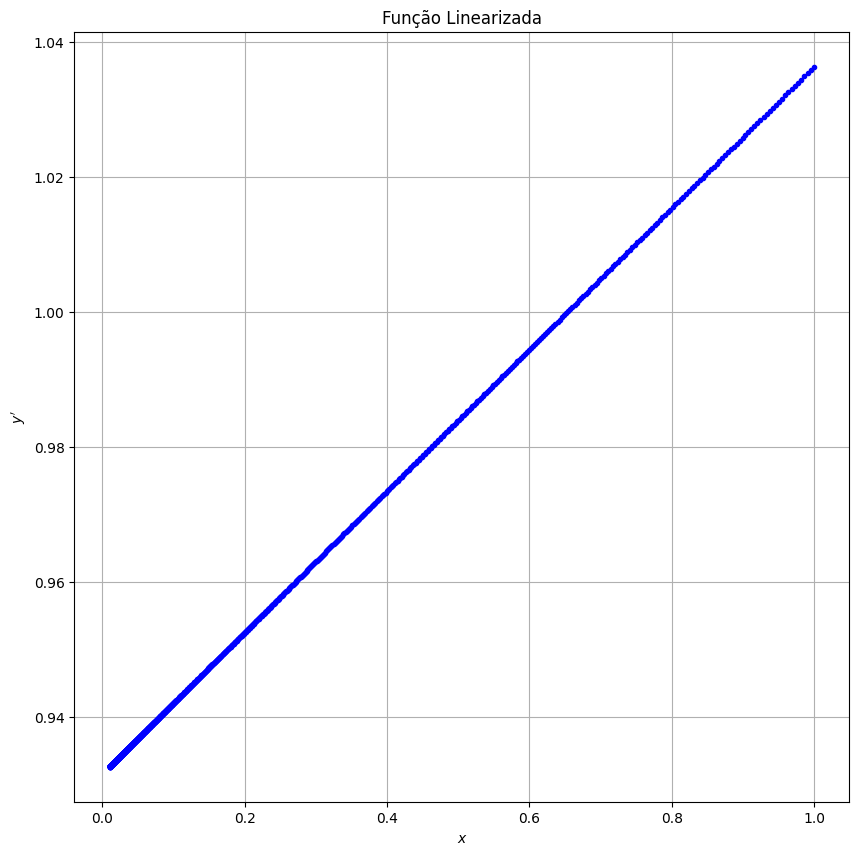

In [ ]:
# Plotando os dados
y_ = a_numpy_plano[0] + a_numpy_plano[1]*x
fig = plt.figure(figsize=(10,10))
plt.plot(x, y_, 'b.', label = "Função Não-Linearizada")
plt.xlabel("$x$")
plt.ylabel("$y'$")
plt.title("Função Linearizada")
plt.grid()
plt.show()

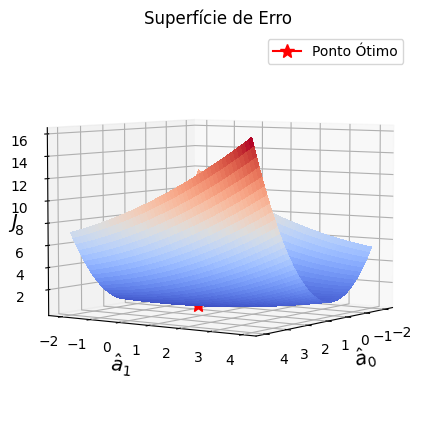

In [ ]:
error_surface_3D_plot (A0, A1, J, a_numpy_plano, Je_optimum_plano)

In [ ]:
def gradiente_descendente_batelada (x1, y_noisy, alpha, maxNumEpoch):
  N = len(y_noisy) # Quantidade de exemplos

  J_gd_batelada = np.zeros(maxNumEpoch + 1) # Inicializa o vetor de MSEs com zeros (o "+1" refere-se ao valor inicial J_gd_batelada[0] a ser calculado fora do laço)

  a_batelada = np.array([-2.0, -2.0]).reshape(2, 1) # Inicialização aleatória dos parâmetros estimados \hat{a}_0 e \hat{a}_1

  a_hist_batelada = np.zeros((2, maxNumEpoch + 1)) # Vetor com os parâmetros estimados a cada iteração, incluindo o inicial aleatório (por isso, "+1")
  a_hist_batelada[:, 0] = a_batelada.reshape(2,) # Posiciona os dois valores de inicialização aleatória, a, nas duas linhas da primeira coluna do histórico. reshape(2,) gera um array 1D, sendo mais adequado que reshape(2,1) que gera uma grandeza 2D

  X = np.c_[np.ones((N,1)), x1]

  # Função hipótese
  y_hat = X.dot(a_batelada)

  # MSE inicial
  J_gd_batelada[0] = (1.0/N)*np.sum(np.power((y_noisy - y_hat),2))
  # J_gd_batelada[0] = (1.0/N)*sum(np.power((y_noisy[:,0] - y_hat[:,0]), 2)) # Alternativa

  # Inicialização da matriz do histórico de gradientes com zeros
  grad_hist_batelada = np.zeros((2, maxNumEpoch))

  # Loop do Gradiente Descendente em Batelada
  error = 1 # Um valor qualquer maior que o erro objetivo. É o erro entre duas épocas consecutivas
  epoch_batelada = 0 # Contador de épocas (uma época equivale à utilização de todos os exemplos de treinamento)
  while (error > 1e-5 and epoch_batelada < maxNumEpoch-1):
    # Cálculo do vetor gradiente
    y_hat = X.dot(a_batelada)
    gradients = -X.T.dot(y_noisy - y_hat)

    # Atualize os pesos
    a_batelada = a_batelada - alpha*gradients

    # Armazena os novos pesos na matriz
    a_hist_batelada[:, epoch_batelada+1] = a_batelada.reshape(2,) # Veja que o a_hist[:,0] foi inicializado/feito antes do loop. Por isso, aqui, utiliza-se a próxima coluna "epoch+1"

    # Calcula e armazena o MSE para os novos pesos
    y_hat = X.dot(a_batelada)
    J_gd_batelada[epoch_batelada+1] = (1.0/N)*np.sum(np.power((y_noisy-y_hat),2))

    # Cálculo do erro entre épocas sucessivas
    error = np.abs(J_gd_batelada[epoch_batelada] - J_gd_batelada[epoch_batelada+1])

    # Atualize o histórico de gradientes
    grad_hist_batelada[:,epoch_batelada] = gradients.reshape(2,) # Feito pela primeira vez aqui dentro do loop, por isso índice "epoch"

    # Incremento da época
    epoch_batelada += 1

  return a_batelada, a_hist_batelada, J_gd_batelada, grad_hist_batelada, epoch_batelada

In [ ]:
# PLOT DA SUPERFÍCIE DE CONTORNO
def error_surface_3D_contour (A1, A2, J, a_numpy_plano):

  fig_ctr = plt.figure(figsize = (5,5))
  cp = plt.contour(A1, A2, J)
  plt.plot([a_numpy_plano[0,0]],[a_numpy_plano[1,0]], c = 'r', marker = '*', markersize = 10, label = 'Ponto Ótimo')
  plt.clabel(cp, inline=1, fontsize=10)
  plt.xlabel('$\hat{a}_0$', fontsize=14)
  plt.ylabel('$\hat{a}_1$', fontsize=14)
  plt.plot(a_hist_batelada[0, 0:epoch_batelada], a_hist_batelada[1, 0:epoch_batelada], 'kx', label='GD')
  plt.title('Superfície de contorno')
  plt.xticks(np.arange(-2, 4, step=2.0)) # ***** Ajustado de acordo com os limites de a1 *****
  plt.yticks(np.arange(-2, 4, step=2.0)) # ***** Ajustado de acordo com os limites de a2 *****

  plt.legend()
  plt.show()

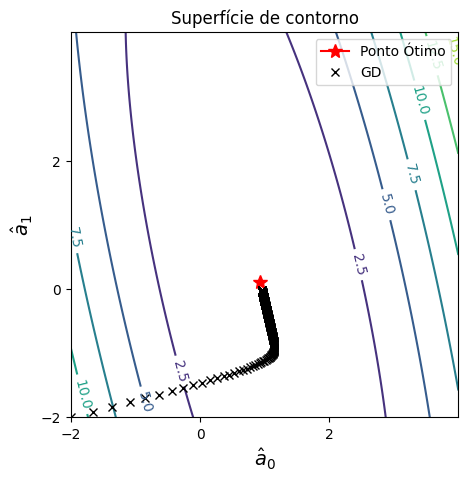

In [ ]:
a_batelada, a_hist_batelada, J_gd_batelada, grad_hist_batelada, epoch_batelada = gradiente_descendente_batelada (x, y, alpha = 0.0001, maxNumEpoch = 1000)
error_surface_3D_contour (A0, A1, J, a_numpy_plano)